# EDA: Reddit Submissions (Arctic Shift archive)

Exploratory analysis of [`open-index/arctic`](https://huggingface.co/datasets/open-index/arctic), a Parquet copy of
the Arctic Shift Reddit dumps (2005-12 to 2026-02, ~2.8B submissions, ~12.9B comments, 1.3 TB).

The project predicts **post success**, so this notebook focuses on **submissions**. Downloading the full archive
is not practical. The notebook samples shards from one month instead.

**NSFW posts (`over_18 = true`) are excluded** from all analysis.

**Sampling note:** the shards in a month are in time order. One shard of 500k rows covers only ~10 hours.
The notebook takes shards spread evenly across the month, so that every day of the week and every hour
are in the sample.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

# Chart style: thin marks, recessive grid, one blue for single-series charts
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
})

/private/tmp/claude-501/-Users-znorton-git-reddit-post-predictor/b748d9c0-e375-4234-9d23-e809649a4ec6/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration and download

In [2]:
REPO = "open-index/arctic"
MONTH = "2025/12"        # YYYY/MM; any month from 2005/12 to 2026/02
N_SHARDS = 12            # ~70 MB and 500k rows (~10 hours of posts) per shard
DATA_DIR = Path("data/arctic")

api = HfApi()
all_shards = sorted(
    f.path for f in api.list_repo_tree(REPO, path_in_repo=f"data/submissions/{MONTH}", repo_type="dataset")
    if f.path.endswith(".parquet")
)
# Take shards spread evenly across the month (shards are in time order)
idx = np.unique(np.linspace(0, len(all_shards) - 1, min(N_SHARDS, len(all_shards))).round().astype(int))
shards = [all_shards[i] for i in idx]
print(f"{len(all_shards)} shards in {MONTH}; using {len(shards)}:")
print(*shards, sep="\n")

86 shards in 2025/12; using 12:
data/submissions/2025/12/000.parquet
data/submissions/2025/12/008.parquet
data/submissions/2025/12/015.parquet
data/submissions/2025/12/023.parquet
data/submissions/2025/12/031.parquet
data/submissions/2025/12/039.parquet
data/submissions/2025/12/046.parquet
data/submissions/2025/12/054.parquet
data/submissions/2025/12/062.parquet
data/submissions/2025/12/070.parquet
data/submissions/2025/12/077.parquet
data/submissions/2025/12/085.parquet


In [3]:
local_files = [
    hf_hub_download(REPO, s, repo_type="dataset", local_dir=DATA_DIR)
    for s in shards
]
con = duckdb.connect()
file_list = ", ".join(f"'{f}'" for f in local_files)
con.execute(f"CREATE OR REPLACE VIEW raw_subs AS SELECT * FROM read_parquet([{file_list}])")
# The project excludes NSFW (over_18) posts. All analysis below uses the `subs` view.
con.execute("CREATE OR REPLACE VIEW subs AS SELECT * FROM raw_subs WHERE NOT coalesce(over_18, false)")
q = lambda sql: con.execute(sql).df()

n_raw, n_nsfw = con.execute("SELECT count(*), count(*) FILTER (over_18) FROM raw_subs").fetchone()
print(f"Excluded {n_nsfw:,} NSFW posts ({n_nsfw / n_raw:.1%}); {n_raw - n_nsfw:,} posts remain")

Excluded 2,748,818 NSFW posts (46.9%); 3,112,265 posts remain


## 2. Schema and overview

In [4]:
q("DESCRIBE subs")

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,author,VARCHAR,YES,None,None,None
2,subreddit,VARCHAR,YES,None,None,None
3,title,VARCHAR,YES,None,None,None
4,selftext,VARCHAR,YES,None,None,None
5,score,BIGINT,YES,None,None,None
6,created_utc,BIGINT,YES,None,None,None
7,created_at,TIMESTAMP,YES,None,None,None
8,title_length,BIGINT,YES,None,None,None
9,num_comments,BIGINT,YES,None,None,None


In [5]:
q("""
SELECT count(*)                    AS n_posts,
       count(DISTINCT id)          AS n_unique_ids,
       count(DISTINCT subreddit)   AS n_subreddits,
       count(DISTINCT author)      AS n_authors,
       min(created_at)             AS first_post,
       max(created_at)             AS last_post
FROM subs
""").T

,0
n_posts,3112265
n_unique_ids,3112265
n_subreddits,182101
n_authors,1514255
first_post,2025-12-01 00:00:00
last_post,2025-12-31 23:59:59


In [6]:
q("SELECT * FROM subs USING SAMPLE 5 ROWS")

,id,author,subreddit,title,selftext,score,created_utc,created_at,title_length,num_comments,url,over_18,link_flair_text,author_flair_text
0,1paxmfe,UseRevolutionary7653,Frenchbulldogs,Color?,What color would you say my boy reggie is? Rescued this guy a couple months ...,30,1764547264,2025-12-01 00:01:04,6,2,https://www.reddit.com/gallery/1paxmfe,False,General Question,None
1,1paxrll,SprinklesBeginning82,OpiniaoBurra,eu não sei da onde o cara tirou que esse filme é uma propaganda política?,???,42,1764547630,2025-12-01 00:07:10,73,20,https://v.redd.it/s3lrclwuhh4g1,False,Opinião ?????,None
2,1pb0hkp,Andstralia,energydrinks,What drinks would you recommend to someone who is naturally caffeine tolerant.,"Hi All! I'm a college student, and as is common, need some energy. However, ...",2,1764555092,2025-12-01 02:11:32,78,10,https://www.reddit.com/r/energydrinks/comments/1pb0hkp/what_drinks_would_you...,False,Suggestion,None
3,1pb3dym,deiqdos749-3,countablepixels,"I need more of these ""card"" memes",,2,1764563451,2025-12-01 04:30:51,33,1,https://www.reddit.com/gallery/1pb3dym,False,NaN,None
4,1pb677s,Smith771does459,Trump_has_dementi,MAGA Mike Suffers TOTAL HUMILIATION with SHOCK CONFESSION,,1,1764572742,2025-12-01 07:05:42,57,0,https://youtu.be/CjsxLEe2g2g?si=_QealBxd5BOquUG8,False,NaN,None


## 3. Data quality

Check for nulls and for the markers that Reddit uses for removed content (`[deleted]`, `[removed]`).
Removed posts are a large part of the raw data. They have almost no score, so they can bias a success model.

In [7]:
cols = [r[0] for r in con.execute("DESCRIBE subs").fetchall()]
nulls = q("SELECT " + ", ".join(f"avg(({c} IS NULL)::INT) AS \"{c}\"" for c in cols) + " FROM subs").T
nulls.columns = ["null_fraction"]
nulls.sort_values("null_fraction", ascending=False)

,null_fraction
author_flair_text,0.889
link_flair_text,0.453
id,0.000
author,0.000
subreddit,0.000
title,0.000
selftext,0.000
score,0.000
created_utc,0.000
created_at,0.000


In [8]:
q("""
SELECT avg((author = '[deleted]')::INT)          AS author_deleted,
       avg((selftext = '[deleted]')::INT)        AS selftext_deleted,
       avg((selftext = '[removed]')::INT)        AS selftext_removed,
       avg((title = '[deleted by user]')::INT)   AS title_deleted_by_user,
       avg((selftext = '' OR selftext IS NULL)::INT) AS selftext_empty
FROM subs
""").T.rename(columns={0: "fraction"})

,fraction
author_deleted,0.013
selftext_deleted,0.009
selftext_removed,0.095
title_deleted_by_user,0.000
selftext_empty,0.342


## 4. Target variables: `score` and `num_comments`

Both are candidate measures of "success". The values are captured at **archival time**.
Arctic Shift collects posts soon after they are created, so the values for some posts are
lower than their final values. Keep this in mind when you define the label.

In [9]:
q("""
SELECT 'score' AS metric, min(score) AS min, quantile_cont(score, [0.25, 0.5, 0.75, 0.9, 0.99, 0.999]) AS quantiles,
       avg(score) AS mean, max(score) AS max FROM subs
UNION ALL
SELECT 'num_comments', min(num_comments), quantile_cont(num_comments, [0.25, 0.5, 0.75, 0.9, 0.99, 0.999]),
       avg(num_comments), max(num_comments) FROM subs
""")

,metric,min,quantiles,mean,max
0,score,0,"[1.0, 1.0, 8.0, 52.0, 819.0, 5629.7360000000335]",51.921,120150
1,num_comments,0,"[0.0, 1.0, 6.0, 20.0, 121.0, 549.0]",9.729,28497


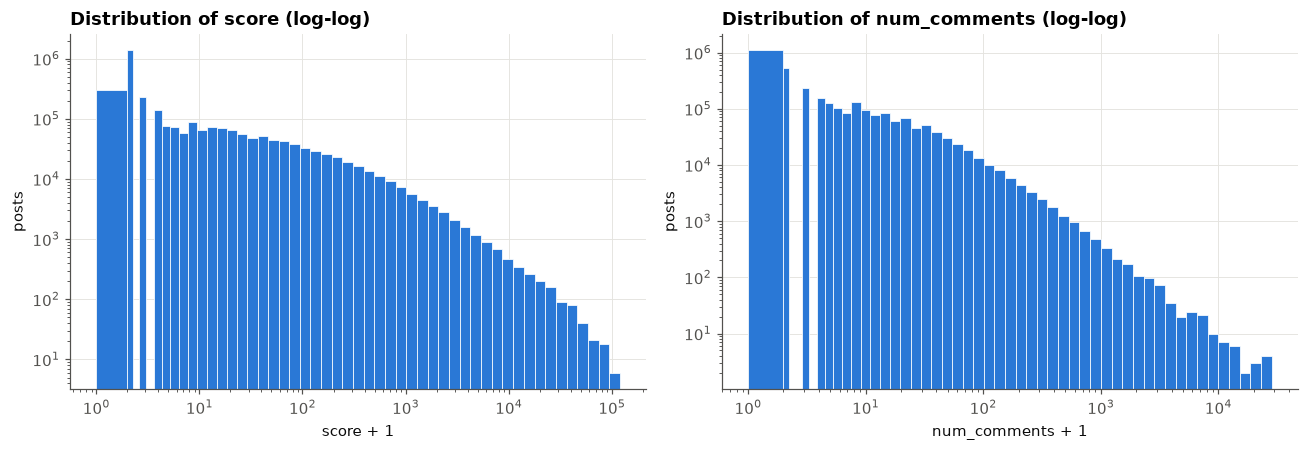

In [10]:
s = q("SELECT score, num_comments FROM subs")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col in zip(axes, ["score", "num_comments"]):
    v = s[col].clip(lower=0)
    bins = np.unique(np.concatenate([[0], np.logspace(0, np.log10(v.max() + 1), 50)]))
    ax.hist(v + 1, bins=bins + 1, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(f"Distribution of {col} (log-log)")
    ax.set_xlabel(f"{col} + 1"); ax.set_ylabel("posts")
plt.tight_layout()

NameError: name 's' is not defined

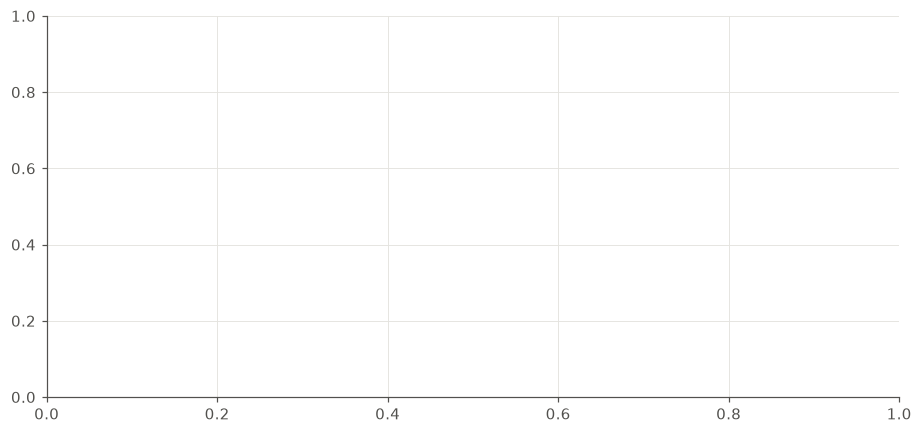

In [6]:
# Complementary CDF: fraction of posts with a value of at least x
fig, ax = plt.subplots()
for col, color in [("score", BLUE), ("num_comments", ORANGE)]:
    v = np.sort(s[col].clip(lower=0).to_numpy())
    ccdf = 1 - np.arange(len(v)) / len(v)
    ax.plot(v + 1, ccdf, color=color, linewidth=2, label=col)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("value + 1"); ax.set_ylabel("P(X ≥ x)")
ax.set_title("Heavy tails: fraction of posts at or above each value")
ax.legend(frameon=False)

Spearman correlation (score, num_comments): 0.463


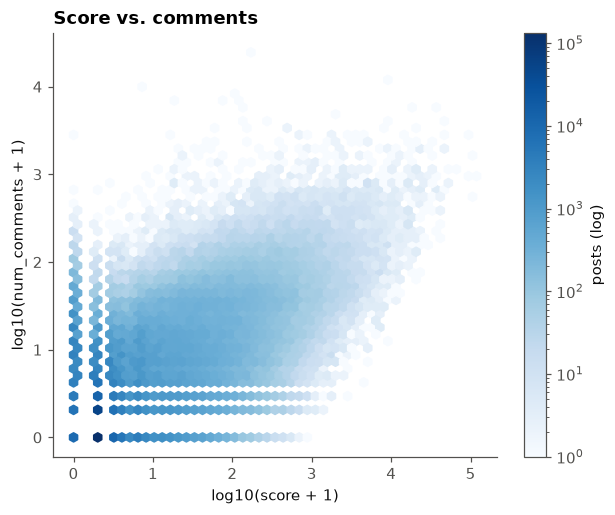

In [12]:
print("Spearman correlation (score, num_comments):",
      round(s[["score", "num_comments"]].corr(method="spearman").iloc[0, 1], 3))

hb = s.sample(min(len(s), 500_000), random_state=0)
fig, ax = plt.subplots(figsize=(6.5, 5))
h = ax.hexbin(np.log10(hb.score.clip(lower=0) + 1), np.log10(hb.num_comments + 1),
              gridsize=50, bins="log", cmap="Blues", mincnt=1)
fig.colorbar(h, ax=ax, label="posts (log)")
ax.set_xlabel("log10(score + 1)"); ax.set_ylabel("log10(num_comments + 1)")
ax.set_title("Score vs. comments"); ax.grid(False)
del s, hb

## 5. Subreddits

The baseline score is very different from one subreddit to the next. A score of 50 is a big success in a small
subreddit and a failure in r/pics. A per-subreddit normalization (for example, a percentile in the subreddit) is
probably necessary for the label.

In [13]:
sub_stats = q("""
SELECT subreddit,
       count(*)                              AS posts,
       median(score)                         AS median_score,
       quantile_cont(score, 0.9)             AS p90_score,
       avg(score)                            AS mean_score,
       median(num_comments)                  AS median_comments
FROM subs GROUP BY subreddit ORDER BY posts DESC
""")
print(f"{len(sub_stats):,} subreddits in sample")
sub_stats.head(25)

182,101 subreddits in sample


,subreddit,posts,median_score,p90_score,mean_score,median_comments
0,chessquiz,22279,1.000,1.000,1.056,1.000
1,FarmMergeValley,20061,1.000,2.000,1.303,0.000
2,AskReddit,17272,1.000,3.000,16.338,4.000
3,SwordAndSupperGame,16359,1.000,3.000,1.737,0.000
4,Pixelary,14828,1.000,1.000,1.043,1.000
5,PokemonGoRaids,13557,1.000,1.000,1.044,0.000
6,automationContentCom,11792,1.000,1.000,1.000,0.000
7,AutoNewspaper,8078,1.000,1.000,1.007,0.000
8,ArcRaiders,6941,1.000,9.000,49.437,2.000
9,teenagers,6925,1.000,5.000,33.439,2.000


top     10 subreddits -> 4.4% of posts
top    100 subreddits -> 11.5% of posts
top  1,000 subreddits -> 30.6% of posts
top 10,000 subreddits -> 69.8% of posts


Text(0.0, 1.0, 'Post volume concentration across subreddits')

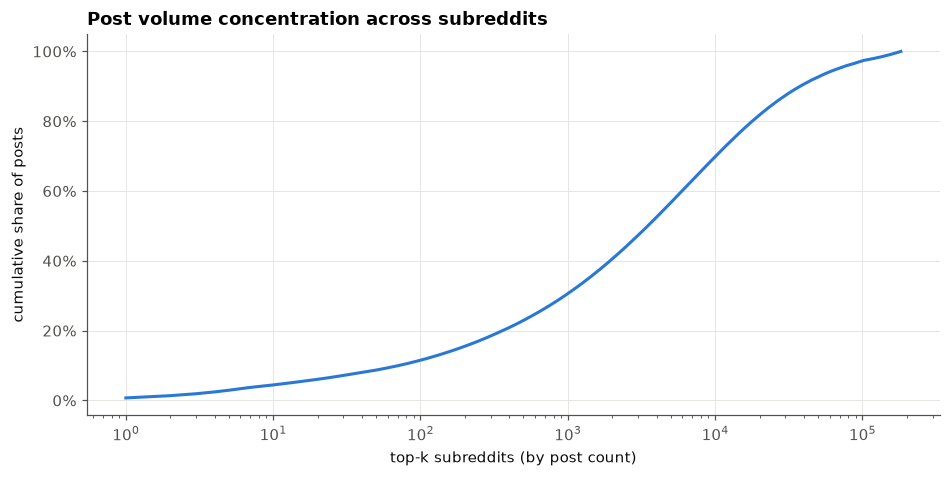

In [14]:
# Concentration: share of all posts that the top-k subreddits contain
cum = sub_stats.posts.cumsum() / sub_stats.posts.sum()
for k in [10, 100, 1_000, 10_000]:
    if k <= len(cum):
        print(f"top {k:>6,} subreddits -> {cum.iloc[k-1]:.1%} of posts")

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cum) + 1), cum.values, color=BLUE, linewidth=2)
ax.set_xscale("log"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("top-k subreddits (by post count)"); ax.set_ylabel("cumulative share of posts")
ax.set_title("Post volume concentration across subreddits")

Text(0.0, 1.0, 'Subreddit activity vs. 90th-percentile score')

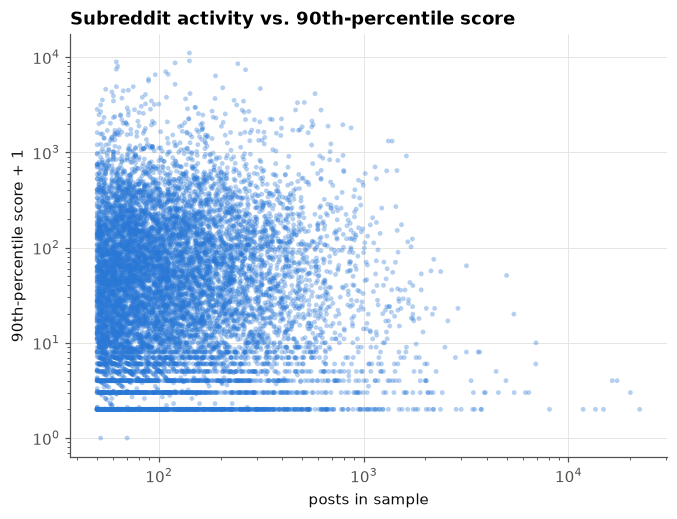

In [15]:
# Subreddit size vs. typical score (subreddits with >= 50 posts in the sample)
big = sub_stats[sub_stats.posts >= 50]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(big.posts, big.p90_score + 1, s=10, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("posts in sample"); ax.set_ylabel("90th-percentile score + 1")
ax.set_title("Subreddit activity vs. 90th-percentile score")

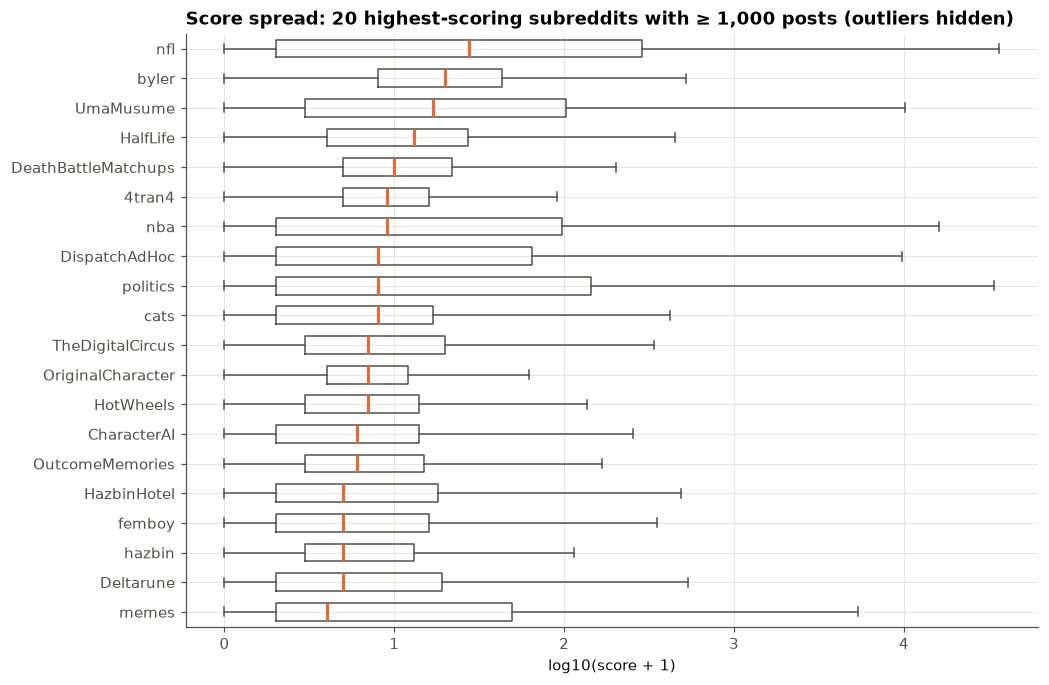

In [16]:
# The busiest subreddits are mostly bots/spam with score 1, so show the 20 active
# subreddits (>= 1,000 posts in the sample) with the highest median score instead
top20 = (sub_stats[sub_stats.posts >= 1_000]
         .sort_values(["median_score", "p90_score"], ascending=False).head(20).subreddit.tolist())
t = q(f"""
SELECT subreddit, score FROM subs
WHERE subreddit IN ({", ".join(f"'{x}'" for x in top20)})
""")
order = t.groupby("subreddit").score.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot([np.log10(t.loc[t.subreddit == x, "score"].clip(lower=0) + 1) for x in order],
           orientation="horizontal", tick_labels=order, showfliers=False, widths=0.6,
           medianprops=dict(color=ORANGE, linewidth=2), boxprops=dict(color=MUTED),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xlabel("log10(score + 1)")
ax.set_title("Score spread: 20 highest-scoring subreddits with ≥ 1,000 posts (outliers hidden)")
del t

## 6. Time of posting

All times are UTC. Each shard is one contiguous block of ~10 hours, so the sample has gaps.
The coverage chart shows which hours of the month are in the sample.
**Post volume by hour or day in this sample shows where the shards fall, not real Reddit activity.**
The rates (share of posts with score ≥ 10) are still valid in each group.

Text(0, 0.5, 'posts')

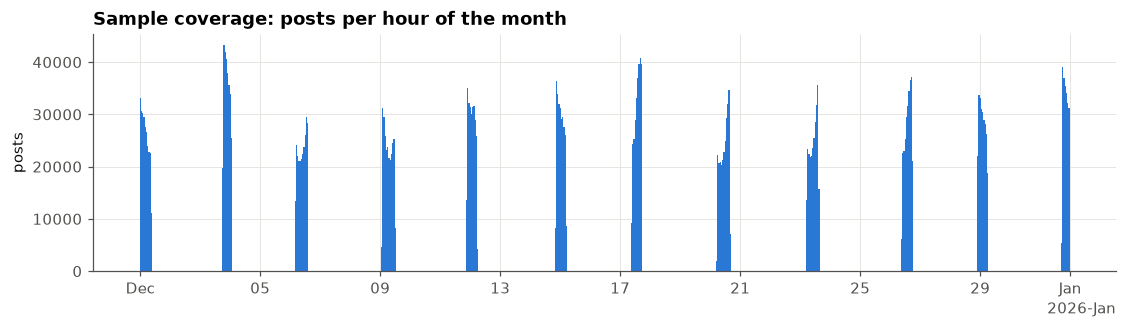

In [17]:
coverage = q("SELECT date_trunc('hour', created_at) AS hour, count(*) AS posts FROM subs GROUP BY 1 ORDER BY 1")
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.bar(coverage.hour, coverage.posts, width=1/24, color=BLUE)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set_title("Sample coverage: posts per hour of the month"); ax.set_ylabel("posts")

,dow,day,posts,median_score,frac_score_ge_10
0,1,Monday,607390,1.000,0.240
1,2,Tuesday,525481,1.000,0.229
2,3,Wednesday,711156,1.000,0.244
3,4,Thursday,140112,1.000,0.244
4,5,Friday,450807,1.000,0.254
5,6,Saturday,511087,1.000,0.196
6,7,Sunday,166232,1.000,0.253


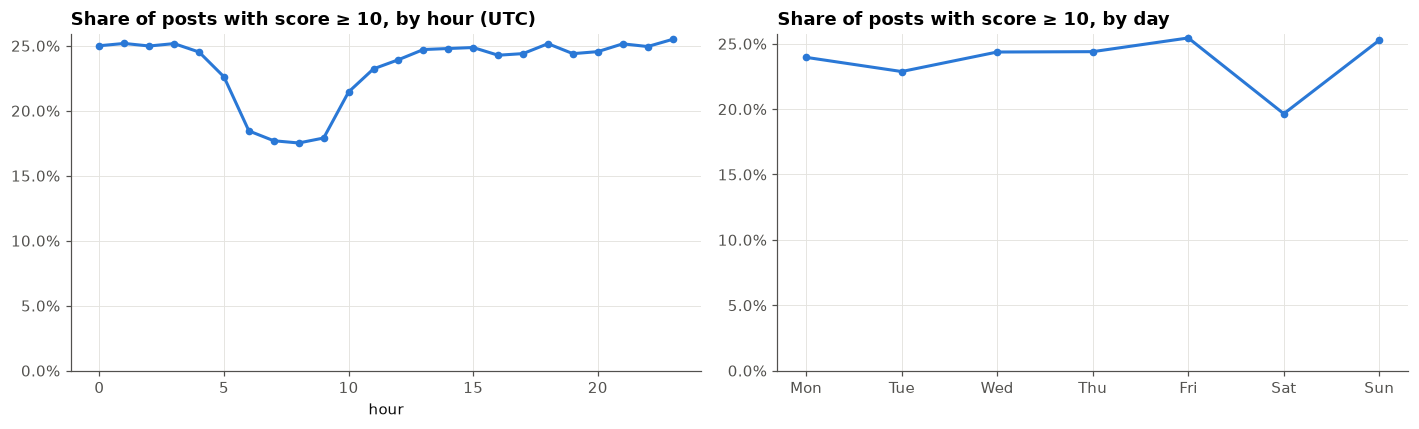

In [18]:
by_hour = q("""
SELECT hour(created_at) AS hour, count(*) AS posts, median(score) AS median_score,
       avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY 1
""")
by_dow = q("""
SELECT isodow(created_at) AS dow, dayname(created_at) AS day, count(*) AS posts,
       median(score) AS median_score, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1, 2 ORDER BY 1
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(by_hour.hour, by_hour.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[0].set_title("Share of posts with score ≥ 10, by hour (UTC)"); axes[0].set_xlabel("hour")
axes[1].plot(by_dow.day.str[:3], by_dow.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=4)
axes[1].set_title("Share of posts with score ≥ 10, by day")
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(bottom=0)
plt.tight_layout()
by_dow

## 7. Post type

The type comes from `url` and `selftext`: self (text) post, image, video, gallery, or external link.

In [19]:
TYPE_SQL = """
CASE
  WHEN url IS NULL OR url = '' THEN 'no url'
  WHEN url LIKE '%reddit.com/r/%/comments/%' OR url LIKE '%reddit.com/r/%/s/%' THEN 'self'
  WHEN url LIKE '%i.redd.it%' OR regexp_matches(lower(url), '\\.(jpg|jpeg|png|gif|webp)$') OR url LIKE '%imgur.com%' THEN 'image'
  WHEN url LIKE '%v.redd.it%' OR url LIKE '%youtube.com%' OR url LIKE '%youtu.be%' THEN 'video'
  WHEN url LIKE '%reddit.com/gallery/%' THEN 'gallery'
  ELSE 'external link'
END
"""
by_type = q(f"""
SELECT {TYPE_SQL} AS post_type, count(*) AS posts, count(*) / sum(count(*)) OVER () AS share,
       median(score) AS median_score, quantile_cont(score, 0.9) AS p90_score,
       median(num_comments) AS median_comments, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY posts DESC
""")
by_type

,post_type,posts,share,median_score,p90_score,median_comments,frac_score_ge_10
0,self,1422578,0.457,1.000,11.000,1.000,0.114
1,image,767895,0.247,5.000,171.000,2.000,0.416
2,gallery,352861,0.113,3.000,99.000,2.000,0.370
3,external link,269250,0.087,1.000,14.000,0.000,0.115
4,video,258640,0.083,2.000,121.000,1.000,0.335
5,no url,41041,0.013,1.000,1.000,0.000,0.008


In [20]:
top_domains = q("""
SELECT regexp_extract(url, '^https?://(?:www\\.)?([^/]+)', 1) AS domain,
       count(*) AS posts, median(score) AS median_score
FROM subs GROUP BY 1 ORDER BY posts DESC LIMIT 20
""")
top_domains

,domain,posts,median_score
0,reddit.com,1783499,1.000
1,i.redd.it,763603,5.000
2,v.redd.it,180059,5.000
3,,105194,1.000
4,youtube.com,42995,1.000
5,youtu.be,34356,1.000
6,theguardian.com,4350,1.000
7,open.spotify.com,3379,1.000
8,bbc.com,2945,1.000
9,jobboardsearch.com,2814,1.000


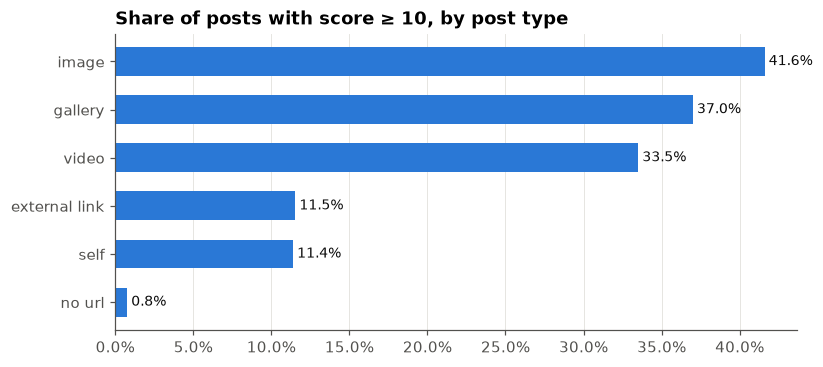

In [21]:
d = by_type.sort_values("frac_score_ge_10")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(d.post_type, d.frac_score_ge_10, color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for y, v in enumerate(d.frac_score_ge_10):
    ax.text(v, y, f" {v:.1%}", va="center", color=INK, fontsize=9)
ax.set_title("Share of posts with score ≥ 10, by post type"); ax.grid(axis="y", visible=False)

## 8. Text features

In [22]:
text = q("""
SELECT score, num_comments, title_length,
       length(coalesce(selftext, '')) AS selftext_length,
       contains(title, '?')                                AS title_has_question,
       regexp_matches(title, '\\d')                      AS title_has_number,
       title = upper(title) AND regexp_matches(title, '[A-Z]') AS title_all_caps,
       len(string_split(title, ' '))                       AS title_words
FROM subs
WHERE coalesce(selftext, '') NOT IN ('[removed]', '[deleted]')
""")
text.describe(percentiles=[0.5, 0.9, 0.99]).T

,count,mean,std,min,50%,90%,99%,max
score,"2,789,936.000",57.763,650.549,0.000,2.000,63.000,906.000,"120,150.000"
num_comments,"2,789,936.000",10.759,76.596,0.000,2.000,22.000,131.000,"28,497.000"
title_length,"2,789,936.000",47.148,38.664,1.000,37.000,89.000,214.000,300.000
selftext_length,"2,789,936.000",353.510,"1,070.190",0.000,89.000,866.000,"3,751.650","41,790.000"
title_words,"2,789,936.000",8.301,6.836,1.000,7.000,16.000,37.000,170.000


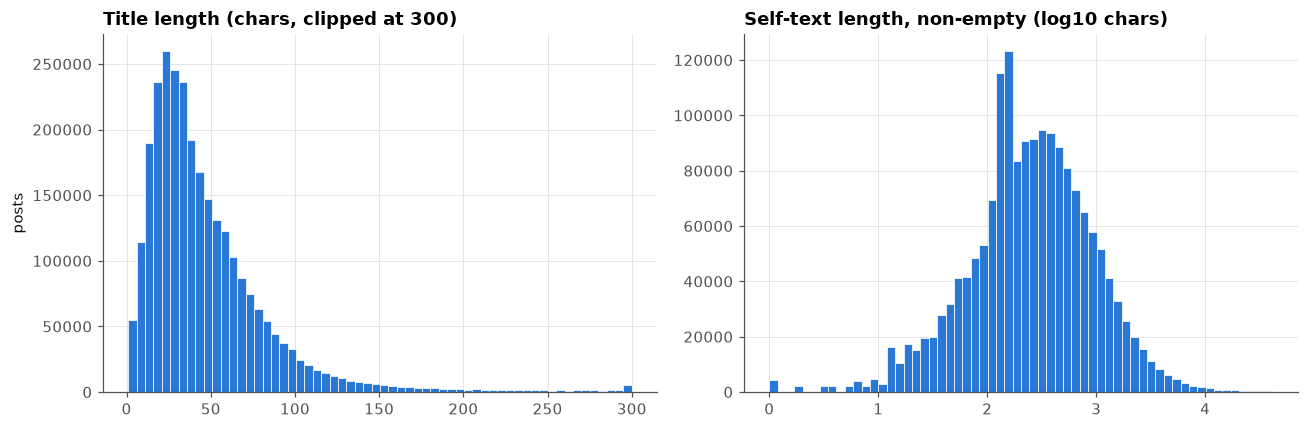

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(text.title_length.clip(upper=300), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("Title length (chars, clipped at 300)"); axes[0].set_ylabel("posts")
sl = text.selftext_length[text.selftext_length > 0]
axes[1].hist(np.log10(sl), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_title("Self-text length, non-empty (log10 chars)")
plt.tight_layout()

,posts,median_score,frac_score_ge_10
title_len_bin,,,
"(0.999, 14.0]",316410,2.000,0.284
"(14.0, 20.0]",278904,2.000,0.287
"(20.0, 25.0]",259729,2.000,0.266
"(25.0, 31.0]",291083,2.000,0.268
"(31.0, 37.0]",271342,1.000,0.245
"(37.0, 45.0]",278624,2.000,0.263
"(45.0, 55.0]",278534,2.000,0.256
"(55.0, 67.0]",262727,1.000,0.237
"(67.0, 89.0]",278267,1.000,0.245


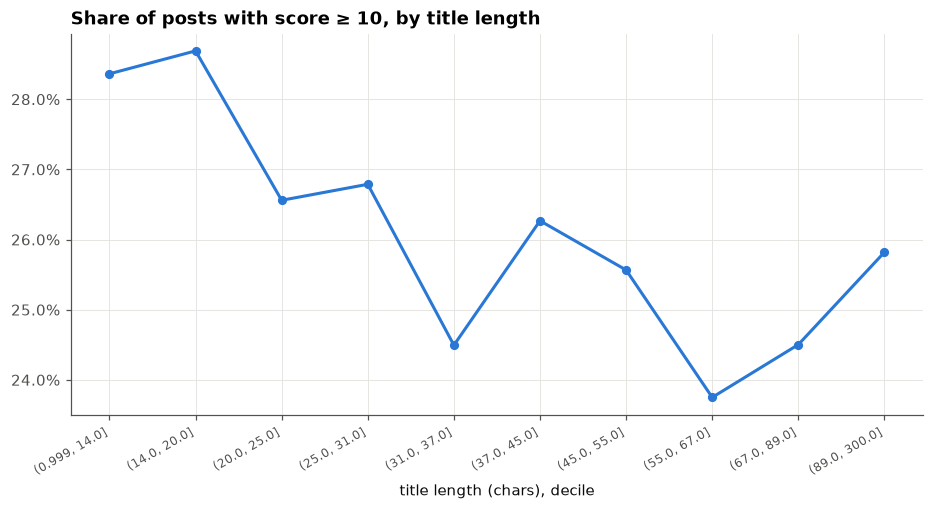

In [24]:
# Median score and share with score >= 10 in title-length deciles
text["title_len_bin"] = pd.qcut(text.title_length, 10, duplicates="drop")
g = text.groupby("title_len_bin", observed=True).agg(
    posts=("score", "size"), median_score=("score", "median"),
    frac_score_ge_10=("score", lambda x: (x >= 10).mean()))
fig, ax = plt.subplots()
ax.plot(range(len(g)), g.frac_score_ge_10, color=BLUE, linewidth=2, marker="o", markersize=5)
ax.set_xticks(range(len(g)), [str(i) for i in g.index], rotation=30, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("title length (chars), decile"); ax.set_title("Share of posts with score ≥ 10, by title length")
g

In [25]:
rows = []
for f in ["title_has_question", "title_has_number", "title_all_caps"]:
    for val, grp in text.groupby(f):
        rows.append({"feature": f, "value": val, "posts": len(grp),
                     "median_score": grp.score.median(), "frac_score_ge_10": (grp.score >= 10).mean()})
pd.DataFrame(rows)

,feature,value,posts,median_score,frac_score_ge_10
0,title_has_question,False,2193070,2.000,0.275
1,title_has_question,True,596866,2.000,0.212
2,title_has_number,False,2097131,2.000,0.280
3,title_has_number,True,692805,1.000,0.206
4,title_all_caps,False,2735088,2.000,0.261
5,title_all_caps,True,54848,1.000,0.255


In [26]:
del text

## 9. Flair and authors

In [27]:
q("""
SELECT link_flair_text IS NOT NULL AS has_flair, count(*) AS posts,
       median(score) AS median_score, avg((score >= 10)::INT) AS frac_score_ge_10
FROM subs GROUP BY 1 ORDER BY 1
""")

,has_flair,posts,median_score,frac_score_ge_10
0,False,1410550,1.000,0.201
1,True,1701715,2.000,0.263


In [28]:
authors = q("""
SELECT author, count(*) AS posts, count(DISTINCT subreddit) AS subreddits, median(score) AS median_score
FROM subs WHERE author <> '[deleted]' GROUP BY author
""")
print(authors.posts.describe(percentiles=[0.5, 0.9, 0.99, 0.999]))
authors.sort_values("posts", ascending=False).head(15)

count   1,514,254.000
mean            2.028
std            25.908
min             1.000
50%             1.000
90%             3.000
99%            12.000
99.9%          49.000
max        22,275.000
Name: posts, dtype: float64


,author,posts,subreddits,median_score
137234,chess-quiz-plus,22275,1,1.000
629997,lss_web_1444,11793,2,1.000
1308764,AutoModerator,9693,3022,1.000
753200,AutoNewsAdmin,8217,27,1.000
94210,AutoNewspaperAdmin,8078,1,1.000
669405,henryzhangpku,4942,19,1.000
1267802,playwright_non_admin,3737,1,1.000
1173847,hatchcats-game,3478,1,1.000
4140,TrackaLackerBot,2920,15,1.000
59656,rrmdp,2814,1,1.000


Text(0.0, 1.0, 'Posts per author')

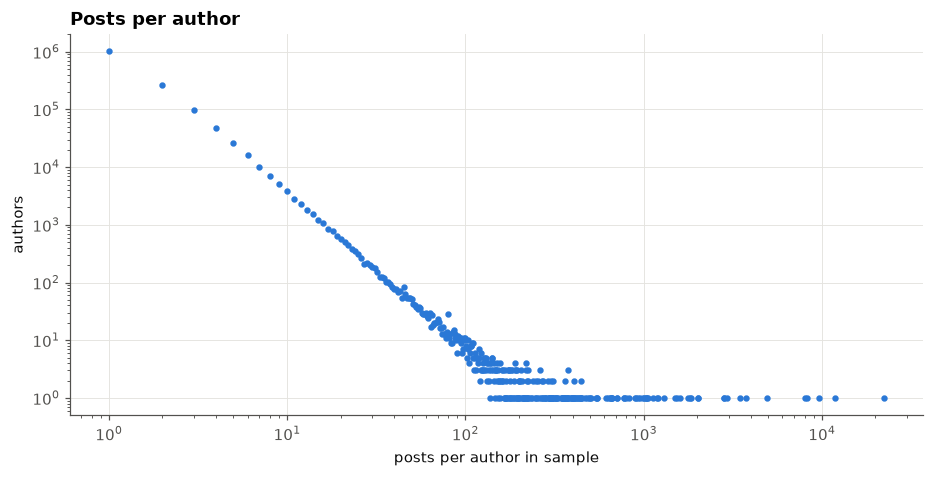

In [29]:
# Authors with many posts in many subreddits are often spam or bot accounts
fig, ax = plt.subplots()
vc = authors.posts.value_counts().sort_index()
ax.scatter(vc.index, vc.values, s=10, color=BLUE)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("posts per author in sample"); ax.set_ylabel("authors")
ax.set_title("Posts per author")

## 10. Possible "success" labels

Some candidate definitions and their class balance. A label relative to the subreddit avoids a model that
only learns "big subreddits get big scores".

In [30]:
labels = q("""
WITH base AS (
  SELECT *, percent_rank() OVER (PARTITION BY subreddit ORDER BY score) AS sub_pct,
         count(*) OVER (PARTITION BY subreddit) AS sub_n
  FROM subs
  WHERE coalesce(selftext, '') NOT IN ('[removed]', '[deleted]') AND author <> '[deleted]'
)
SELECT count(*)                                         AS posts_after_filter,
       avg((score >= 10)::INT)                          AS score_ge_10,
       avg((score >= 100)::INT)                         AS score_ge_100,
       avg((num_comments >= 10)::INT)                   AS comments_ge_10,
       avg((sub_pct >= 0.9)::INT) FILTER (sub_n >= 50)  AS top10pct_in_subreddit,
       count(*) FILTER (sub_n >= 50)                    AS posts_in_subs_ge_50
FROM base
""")
labels.T.rename(columns={0: "value"})

,value
posts_after_filter,"2,789,457.000"
score_ge_10,0.261
score_ge_100,0.073
comments_ge_10,0.213
top10pct_in_subreddit,0.088
posts_in_subs_ge_50,"1,947,217.000"


## Summary

Fill in after you run the notebook. Questions to answer:

- How much of the data is removed or deleted, and do we drop it?
- How heavy are the tails of `score` and `num_comments`? A log transform or a classification label is probably necessary.
- How much does the subreddit explain? Do we normalize the label in each subreddit?
- Which simple features (time, post type, title length, flair) show a signal?
- Is the archival-time `score` mature enough to use as a target, or do we use an older month?